Import all libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost
import shap
import streamlit



Load & Explore Data

In [25]:
df = pd.read_csv('Palo Alto Networks.csv')
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("SUCCESS - all libraries working!")
df.head()

Rows: 1470
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
SUCCESS - all libraries working!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


Check Missing Values

In [26]:
print("Missing values in each column:")
print(df.isnull().sum())
print()
print(f"Total missing: {df.isnull().sum().sum()}")

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

Total missing: 0


 Check The Target Column

In [27]:
print("How many employees LEFT vs STAYED:")
print(df['Attrition'].value_counts())
print()
print(f"Attrition Rate: {df['Attrition'].mean()*100:.1f}%")

How many employees LEFT vs STAYED:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition Rate: 16.1%


Show the Chart

Chart 1:Attrition Overview

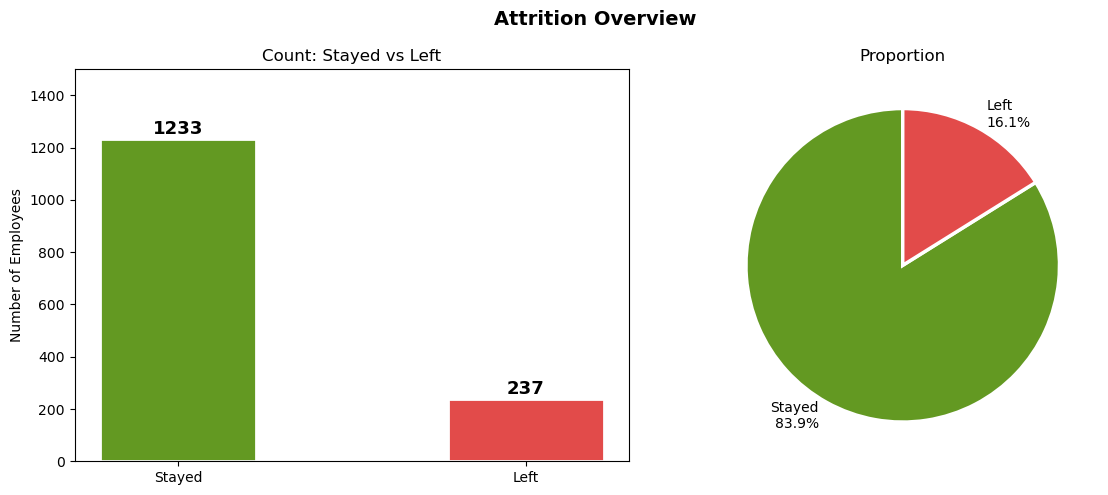

In [28]:
stayed = (df['Attrition'] == 0).sum()
left   = (df['Attrition'] == 1).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Attrition Overview', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(['Stayed', 'Left'], [stayed, left],
                   color=['#639922', '#E24B4A'],
                   width=0.45, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Number of Employees')
axes[0].set_title('Count: Stayed vs Left')
axes[0].set_ylim(0, 1500)
for bar, val in zip(bars, [stayed, left]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, str(val),
                 ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie([stayed, left],
            labels=['Stayed\n83.9%', 'Left\n16.1%'],
            colors=['#639922', '#E24B4A'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2.5))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('chart1_attrition.png', bbox_inches='tight')
plt.show()


 Chart 2: Department & Job Role

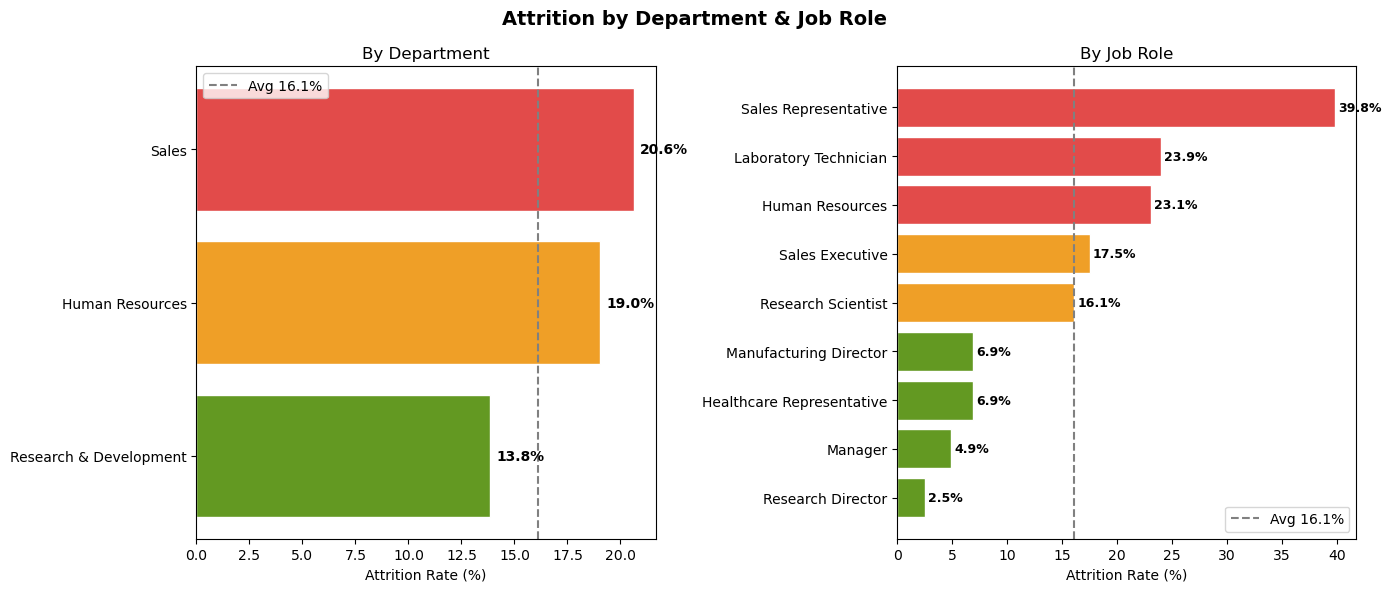

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Attrition by Department & Job Role', fontsize=14, fontweight='bold')

# Department
dept = df.groupby('Department')['Attrition'].mean().mul(100).sort_values()
c = ['#639922' if v < 16 else '#EF9F27' if v < 20 else '#E24B4A' for v in dept.values]
bars = axes[0].barh(dept.index, dept.values, color=c, edgecolor='white')
axes[0].axvline(16.1, color='gray', linestyle='--', linewidth=1.5, label='Avg 16.1%')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_title('By Department')
axes[0].legend()
for b, v in zip(bars, dept.values):
    axes[0].text(v + 0.3, b.get_y() + b.get_height()/2,
                 f'{v:.1f}%', va='center', fontweight='bold')

# Job Role
role = df.groupby('JobRole')['Attrition'].mean().mul(100).sort_values()
c2 = ['#639922' if v < 10 else '#EF9F27' if v < 20 else '#E24B4A' for v in role.values]
bars2 = axes[1].barh(role.index, role.values, color=c2, edgecolor='white')
axes[1].axvline(16.1, color='gray', linestyle='--', linewidth=1.5, label='Avg 16.1%')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('By Job Role')
axes[1].legend()
for b, v in zip(bars2, role.values):
    axes[1].text(v + 0.3, b.get_y() + b.get_height()/2,
                 f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_dept_role.png', bbox_inches='tight')
plt.show()


 Chart 3: Overtime & Marital Status

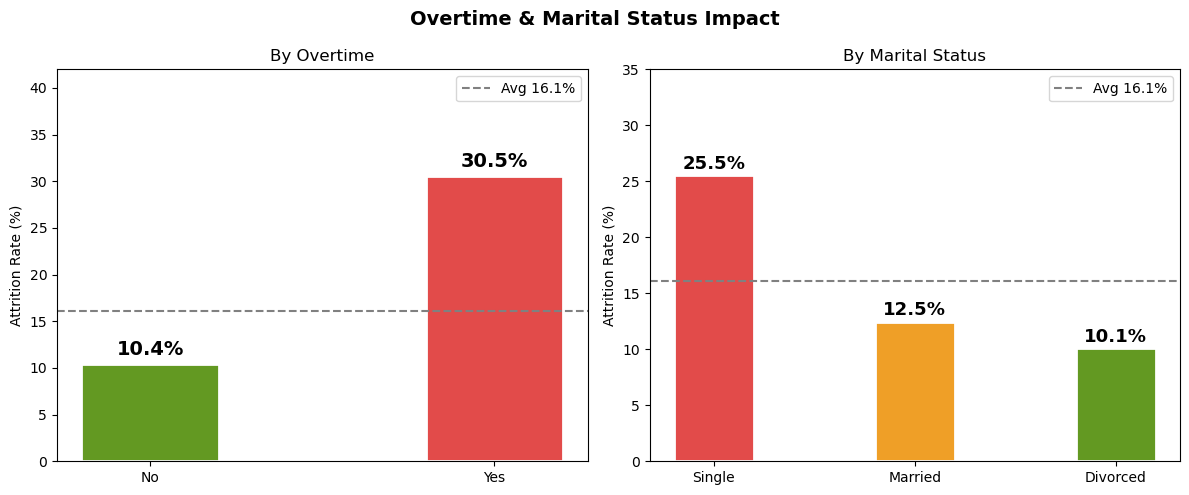

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Overtime & Marital Status Impact', fontsize=14, fontweight='bold')

# Overtime
ot = df.groupby('OverTime')['Attrition'].mean().mul(100)
axes[0].bar(ot.index, ot.values,
            color=['#639922', '#E24B4A'],
            width=0.4, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('By Overtime')
axes[0].set_ylim(0, 42)
axes[0].axhline(16.1, color='gray', linestyle='--', linewidth=1.5, label='Avg 16.1%')
axes[0].legend()
for i, (idx, val) in enumerate(ot.items()):
    axes[0].text(i, val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=14)

# Marital Status
ms = df.groupby('MaritalStatus')['Attrition'].mean().mul(100).sort_values(ascending=False)
c = ['#E24B4A' if v > 20 else '#EF9F27' if v > 12 else '#639922' for v in ms.values]
axes[1].bar(ms.index, ms.values, color=c,
            width=0.4, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('By Marital Status')
axes[1].set_ylim(0, 35)
axes[1].axhline(16.1, color='gray', linestyle='--', linewidth=1.5, label='Avg 16.1%')
axes[1].legend()
for i, (idx, val) in enumerate(ms.items()):
    axes[1].text(i, val + 0.6, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('chart3_overtime_marital.png', bbox_inches='tight')
plt.show()


Chart 4: Monthly Income

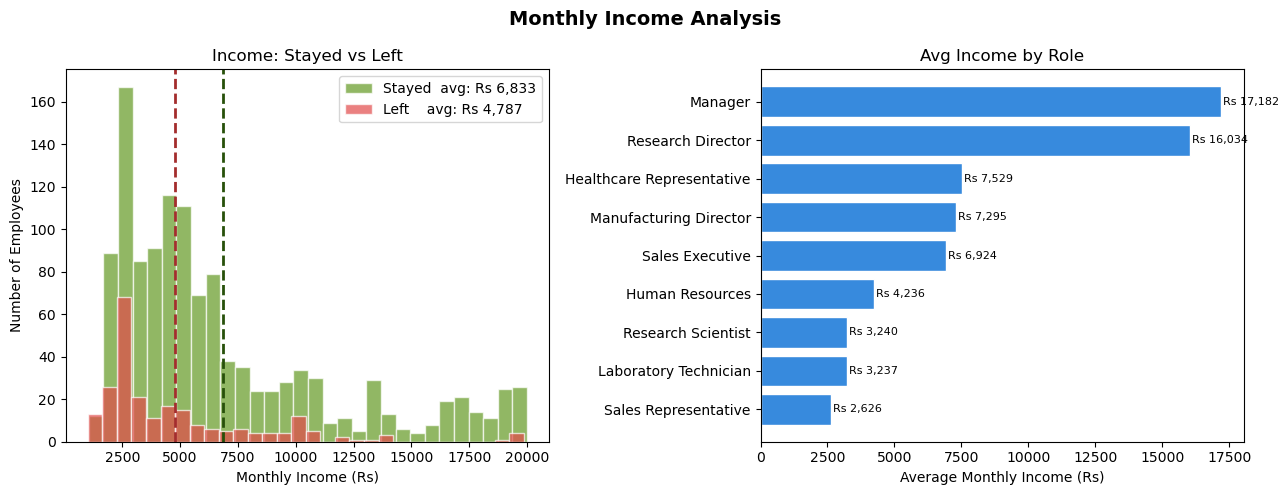

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Monthly Income Analysis', fontsize=14, fontweight='bold')

stayed_inc = df[df['Attrition'] == 0]['MonthlyIncome']
left_inc   = df[df['Attrition'] == 1]['MonthlyIncome']

# Histogram
axes[0].hist(stayed_inc, bins=30, color='#639922', alpha=0.7,
             edgecolor='white', label=f'Stayed  avg: Rs {stayed_inc.mean():,.0f}')
axes[0].hist(left_inc,   bins=30, color='#E24B4A', alpha=0.7,
             edgecolor='white', label=f'Left    avg: Rs {left_inc.mean():,.0f}')
axes[0].axvline(stayed_inc.mean(), color='#27500A', linestyle='--', linewidth=2)
axes[0].axvline(left_inc.mean(),   color='#A32D2D', linestyle='--', linewidth=2)
axes[0].set_xlabel('Monthly Income (Rs)')
axes[0].set_ylabel('Number of Employees')
axes[0].set_title('Income: Stayed vs Left')
axes[0].legend()

# Average by role
role_inc = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values()
axes[1].barh(role_inc.index, role_inc.values, color='#378ADD', edgecolor='white')
axes[1].set_xlabel('Average Monthly Income (Rs)')
axes[1].set_title('Avg Income by Role')
for i, val in enumerate(role_inc.values):
    axes[1].text(val + 80, i, f'Rs {val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart4_income.png', bbox_inches='tight')
plt.show()


Chart 5: Satisfaction Scores

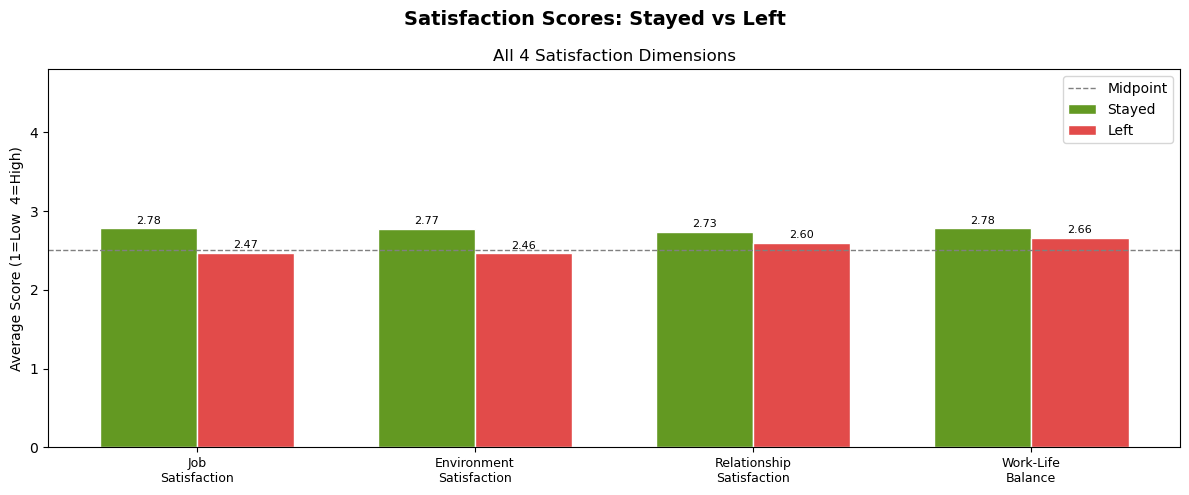

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Satisfaction Scores: Stayed vs Left', fontsize=14, fontweight='bold')

sat_cols   = ['JobSatisfaction', 'EnvironmentSatisfaction',
              'RelationshipSatisfaction', 'WorkLifeBalance']
sat_labels = ['Job\nSatisfaction', 'Environment\nSatisfaction',
              'Relationship\nSatisfaction', 'Work-Life\nBalance']

stayed_m = df[df['Attrition'] == 0][sat_cols].mean()
left_m   = df[df['Attrition'] == 1][sat_cols].mean()

x = np.arange(len(sat_cols))
w = 0.35
b1 = ax.bar(x - w/2, stayed_m, w, color='#639922', label='Stayed', edgecolor='white')
b2 = ax.bar(x + w/2, left_m,   w, color='#E24B4A', label='Left',   edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sat_labels, fontsize=9)
ax.set_ylabel('Average Score (1=Low  4=High)')
ax.set_ylim(0, 4.8)
ax.set_title('All 4 Satisfaction Dimensions')
ax.axhline(2.5, color='gray', linestyle='--', linewidth=1, label='Midpoint')
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.06,
            f'{b.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart5_satisfaction.png', bbox_inches='tight')
plt.show()


Chart 6: Correlation Heatmap

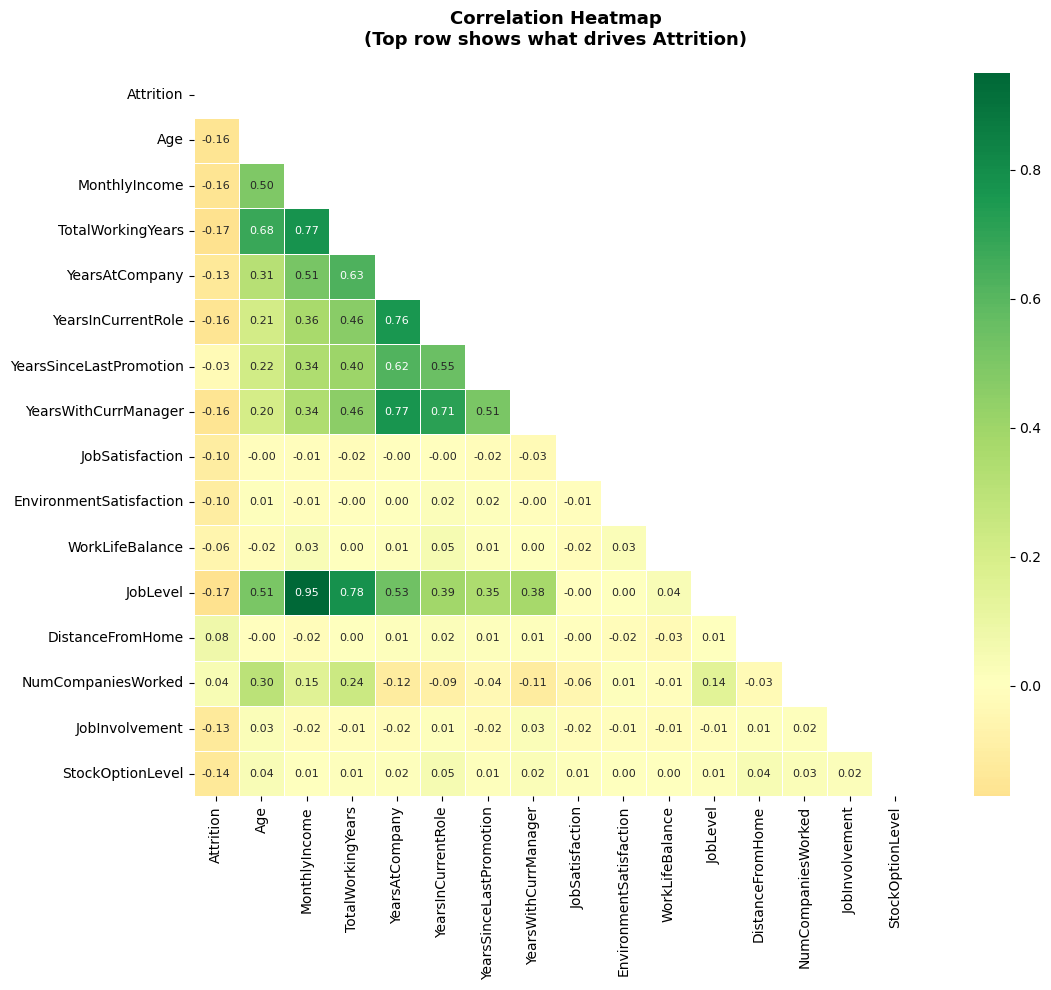

In [33]:
plt.figure(figsize=(13, 10))
plt.title('Correlation Heatmap\n(Top row shows what drives Attrition)',
          fontsize=13, fontweight='bold', pad=20)

num_cols = ['Attrition', 'Age', 'MonthlyIncome', 'TotalWorkingYears',
            'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
            'YearsWithCurrManager', 'JobSatisfaction', 'EnvironmentSatisfaction',
            'WorkLifeBalance', 'JobLevel', 'DistanceFromHome',
            'NumCompaniesWorked', 'JobInvolvement', 'StockOptionLevel']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, annot_kws={'size': 8})

plt.tight_layout()
plt.savefig('chart6_heatmap.png', bbox_inches='tight')
plt.show()


Final summary for research paper

In [35]:
print("=" * 55)
print("  EDA SUMMARY — PALO ALTO NETWORKS")
print("=" * 55)

ot_yes = df[df['OverTime']=='Yes']['Attrition'].mean()*100
ot_no  = df[df['OverTime']=='No']['Attrition'].mean()*100
sal_l  = df[df['Attrition']==1]['MonthlyIncome'].mean()
sal_s  = df[df['Attrition']==0]['MonthlyIncome'].mean()
sin    = df[df['MaritalStatus']=='Single']['Attrition'].mean()*100
mar    = df[df['MaritalStatus']=='Married']['Attrition'].mean()*100
div    = df[df['MaritalStatus']=='Divorced']['Attrition'].mean()*100

print(f"\n  DATASET FACTS")
print(f"  Total employees  : 1,470")
print(f"  Employees left   : 237")
print(f"  Employees stayed : 1,233")
print(f"  Attrition rate   : 16.1%")
print(f"  Missing values   : 0  (data is clean!)")

print(f"\n  FINDING 1 — Attrition Overview")
print(f"  83.9% stayed vs 16.1% left")
print(f"  Data is imbalanced — SMOTE needed in Phase 3!")

print(f"\n  FINDING 2 — Department & Job Role")
print(f"  Highest risk dept : Sales (20.6%)")
print(f"  Highest risk role : Sales Representative (39.8%)")
print(f"  Safest role       : Research Director (2.5%)")

print(f"\n  FINDING 3 — Overtime & Marital Status")
print(f"  Overtime Yes : {ot_yes:.1f}%   Overtime No : {ot_no:.1f}%")
print(f"  Overtime workers leave {ot_yes/ot_no:.1f}x more often!")
print(f"  Single   : {sin:.1f}%  Married : {mar:.1f}%  Divorced : {div:.1f}%")

print(f"\n  FINDING 4 — Monthly Income")
print(f"  Leavers avg salary  : Rs {sal_l:,.0f}/month")
print(f"  Stayers avg salary  : Rs {sal_s:,.0f}/month")
print(f"  Salary gap          : Rs {sal_s-sal_l:,.0f}/month")

print(f"\n  FINDING 5 — Satisfaction Scores")
print(f"  Leavers score lower in ALL 4 dimensions:")
js_l = df[df['Attrition']==1]['JobSatisfaction'].mean()
js_s = df[df['Attrition']==0]['JobSatisfaction'].mean()
es_l = df[df['Attrition']==1]['EnvironmentSatisfaction'].mean()
es_s = df[df['Attrition']==0]['EnvironmentSatisfaction'].mean()
wl_l = df[df['Attrition']==1]['WorkLifeBalance'].mean()
wl_s = df[df['Attrition']==0]['WorkLifeBalance'].mean()
print(f"  Job Satisfaction     : Stayed {js_s:.2f}  Left {js_l:.2f}")
print(f"  Env Satisfaction     : Stayed {es_s:.2f}  Left {es_l:.2f}")
print(f"  Work-Life Balance    : Stayed {wl_s:.2f}  Left {wl_l:.2f}")

print(f"\n  FINDING 6 — Correlation Heatmap")
print(f"  Top features correlated with Attrition:")
print(f"  MonthlyIncome     : negative (higher pay = stays)")
print(f"  TotalWorkingYears : negative (more exp = stays)")
print(f"  YearsAtCompany    : negative (longer tenure = stays)")
print(f"  JobLevel          : negative (senior = stays)")

print(f"\n{'=' * 55}")
print(f"  6 CHARTS COMPLETED!")
print(f"  EDA PHASE IS COMPLETE!")
print(f"  Next: Phase 3 — Data Preprocessing & ML Model")
print(f"{'=' * 55}")

  EDA SUMMARY — PALO ALTO NETWORKS

  DATASET FACTS
  Total employees  : 1,470
  Employees left   : 237
  Employees stayed : 1,233
  Attrition rate   : 16.1%
  Missing values   : 0  (data is clean!)

  FINDING 1 — Attrition Overview
  83.9% stayed vs 16.1% left
  Data is imbalanced — SMOTE needed in Phase 3!

  FINDING 2 — Department & Job Role
  Highest risk dept : Sales (20.6%)
  Highest risk role : Sales Representative (39.8%)
  Safest role       : Research Director (2.5%)

  FINDING 3 — Overtime & Marital Status
  Overtime Yes : 30.5%   Overtime No : 10.4%
  Overtime workers leave 2.9x more often!
  Single   : 25.5%  Married : 12.5%  Divorced : 10.1%

  FINDING 4 — Monthly Income
  Leavers avg salary  : Rs 4,787/month
  Stayers avg salary  : Rs 6,833/month
  Salary gap          : Rs 2,046/month

  FINDING 5 — Satisfaction Scores
  Leavers score lower in ALL 4 dimensions:
  Job Satisfaction     : Stayed 2.78  Left 2.47
  Env Satisfaction     : Stayed 2.77  Left 2.46
  Work-Life Bala